ARTI308 - Machine Learning

# Credit Card Customer Segmentation Project

In this project, you will use K-Means clustering to segment [credit card customers](https://www.kaggle.com/datasets/arjunbhasin2013/ccdata/data) based on their usage behavior. This is an unsupervised learning problem because the dataset does not contain a target label for customer groups.

You will use the `CC_GENERAL.csv` dataset.

## About the Dataset

The dataset contains customer-level credit card usage behavior. Each row represents one credit card holder, and the columns describe different behavioral variables such as balance, purchases, cash advance, payments, and tenure. The goal is to group similar customers together so that the company can understand different customer segments and design better marketing strategies.

## Import Libraries

**Import the libraries you need for data analysis, visualization, preprocessing, clustering, and evaluation.**

In [55]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

%matplotlib inline

## Get the Data

**Read the `CC_GENERAL.csv` file and save it in a dataframe called `df`.**

In [56]:
 df = pd.read_csv('CC_GENERAL.csv')

**Check the first five rows of the dataset.**

In [57]:
 display(df.head())

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


**Check the shape of the dataset.**

In [58]:
 print("Data Shape:", df.shape)

Data Shape: (8950, 18)


**Check basic information about the dataset using `info()`.**

In [59]:
 df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUST_ID                           8950 non-null   object 
 1   BALANCE                           8950 non-null   float64
 2   BALANCE_FREQUENCY                 8950 non-null   float64
 3   PURCHASES                         8950 non-null   float64
 4   ONEOFF_PURCHASES                  8950 non-null   float64
 5   INSTALLMENTS_PURCHASES            8950 non-null   float64
 6   CASH_ADVANCE                      8950 non-null   float64
 7   PURCHASES_FREQUENCY               8950 non-null   float64
 8   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 9   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 10  CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 11  CASH_ADVANCE_TRX                  8950 non-null   int64  
 12  PURCHA

**Check summary statistics using `describe()`.**

In [60]:
 display(df.describe())

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
count,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8949.000000,8950.000000,8637.000000,8950.000000,8950.000000
mean,1564.474828,0.877271,1003.204834,592.437371,411.067645,978.871112,0.490351,0.202458,0.364437,0.135144,3.248827,14.709832,4494.449450,1733.143852,864.206542,0.153715,11.517318
std,2081.531879,0.236904,2136.634782,1659.887917,904.338115,2097.163877,0.401371,0.298336,0.397448,0.200121,6.824647,24.857649,3638.815725,2895.063757,2372.446607,0.292499,1.338331
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,50.000000,0.000000,0.019163,0.000000,6.000000
25%,128.281915,0.888889,39.635000,0.000000,0.000000,0.000000,0.083333,0.000000,0.000000,0.000000,0.000000,1.000000,1600.000000,383.276166,169.123707,0.000000,12.000000
50%,873.385231,1.000000,361.280000,38.000000,89.000000,0.000000,0.500000,0.083333,0.166667,0.000000,0.000000,7.000000,3000.000000,856.901546,312.343947,0.000000,12.000000
75%,2054.140036,1.000000,1110.130000,577.405000,468.637500,1113.821139,0.916667,0.300000,0.750000,0.222222,4.000000,17.000000,6500.000000,1901.134317,825.485459,0.142857,12.000000
max,19043.138560,1.000000,49039.570000,40761.250000,22500.000000,47137.211760,1.000000,1.000000,1.000000,1.500000,123.000000,358.000000,30000.000000,50721.483360,76406.207520,1.000000,12.000000


## Data Cleaning

The column `CUST_ID` is an identification column. It is not useful for clustering because it does not describe customer behavior.

**Drop the `CUST_ID` column from the dataframe.**

In [61]:
 df = df.drop('CUST_ID', axis=1)

**Check the missing values in each column.**

In [62]:
 print("Missing values before cleaning:\n", df.isnull().sum())

Missing values before cleaning:
 BALANCE                               0
BALANCE_FREQUENCY                     0
PURCHASES                             0
ONEOFF_PURCHASES                      0
INSTALLMENTS_PURCHASES                0
CASH_ADVANCE                          0
PURCHASES_FREQUENCY                   0
ONEOFF_PURCHASES_FREQUENCY            0
PURCHASES_INSTALLMENTS_FREQUENCY      0
CASH_ADVANCE_FREQUENCY                0
CASH_ADVANCE_TRX                      0
PURCHASES_TRX                         0
CREDIT_LIMIT                          1
PAYMENTS                              0
MINIMUM_PAYMENTS                    313
PRC_FULL_PAYMENT                      0
TENURE                                0
dtype: int64


Some columns may contain missing values.

Hint: You can handle missing values by either:
- filling them with the mean value
- or dropping the rows that contain missing values

For this project, use mean imputation.

**Fill the missing values with the mean of each column.**

In [63]:
 df = df.fillna(df.mean())

**Check the missing values again to make sure they were handled.**

In [64]:
 print("\nMissing values after cleaning:\n", df.isnull().sum())


Missing values after cleaning:
 BALANCE                             0
BALANCE_FREQUENCY                   0
PURCHASES                           0
ONEOFF_PURCHASES                    0
INSTALLMENTS_PURCHASES              0
CASH_ADVANCE                        0
PURCHASES_FREQUENCY                 0
ONEOFF_PURCHASES_FREQUENCY          0
PURCHASES_INSTALLMENTS_FREQUENCY    0
CASH_ADVANCE_FREQUENCY              0
CASH_ADVANCE_TRX                    0
PURCHASES_TRX                       0
CREDIT_LIMIT                        0
PAYMENTS                            0
MINIMUM_PAYMENTS                    0
PRC_FULL_PAYMENT                    0
TENURE                              0
dtype: int64


## Exploratory Data Analysis

Before applying clustering, it is important to understand the data.

**Create histograms for the numerical columns.**

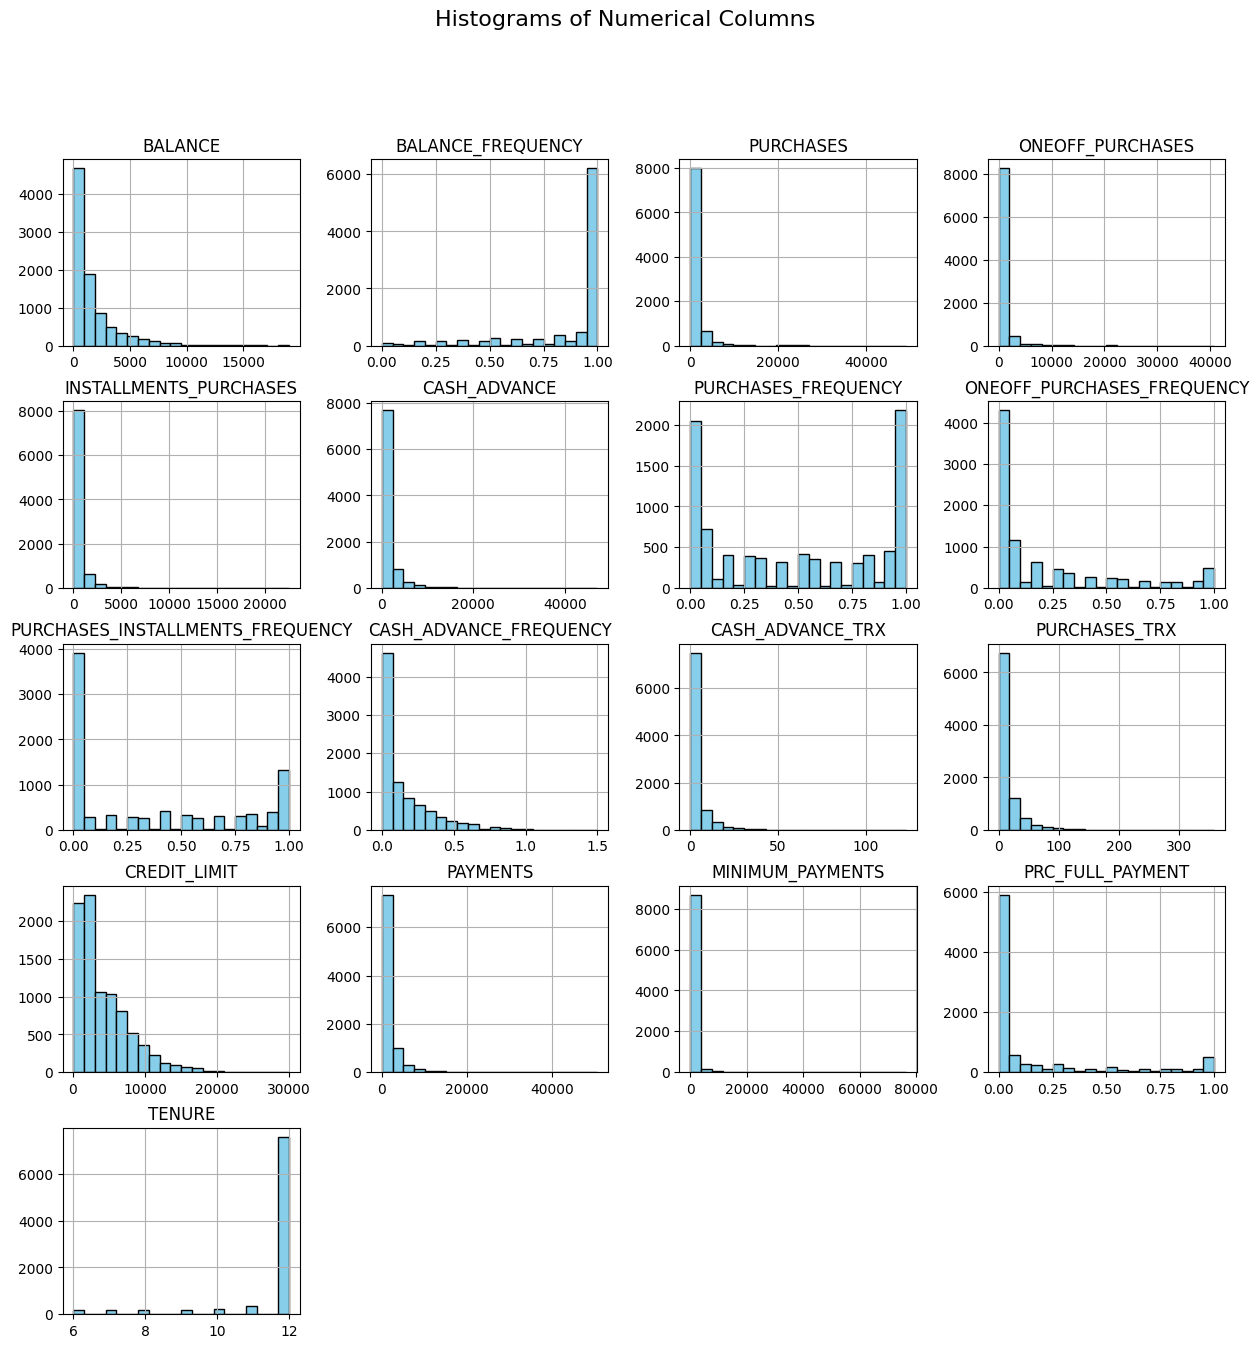

In [65]:
df.hist(figsize=(15, 15), bins=20, color='skyblue', edgecolor='black')
plt.suptitle('Histograms of Numerical Columns', fontsize=16)
plt.show()

**Create a correlation heatmap to understand relationships between the features.**

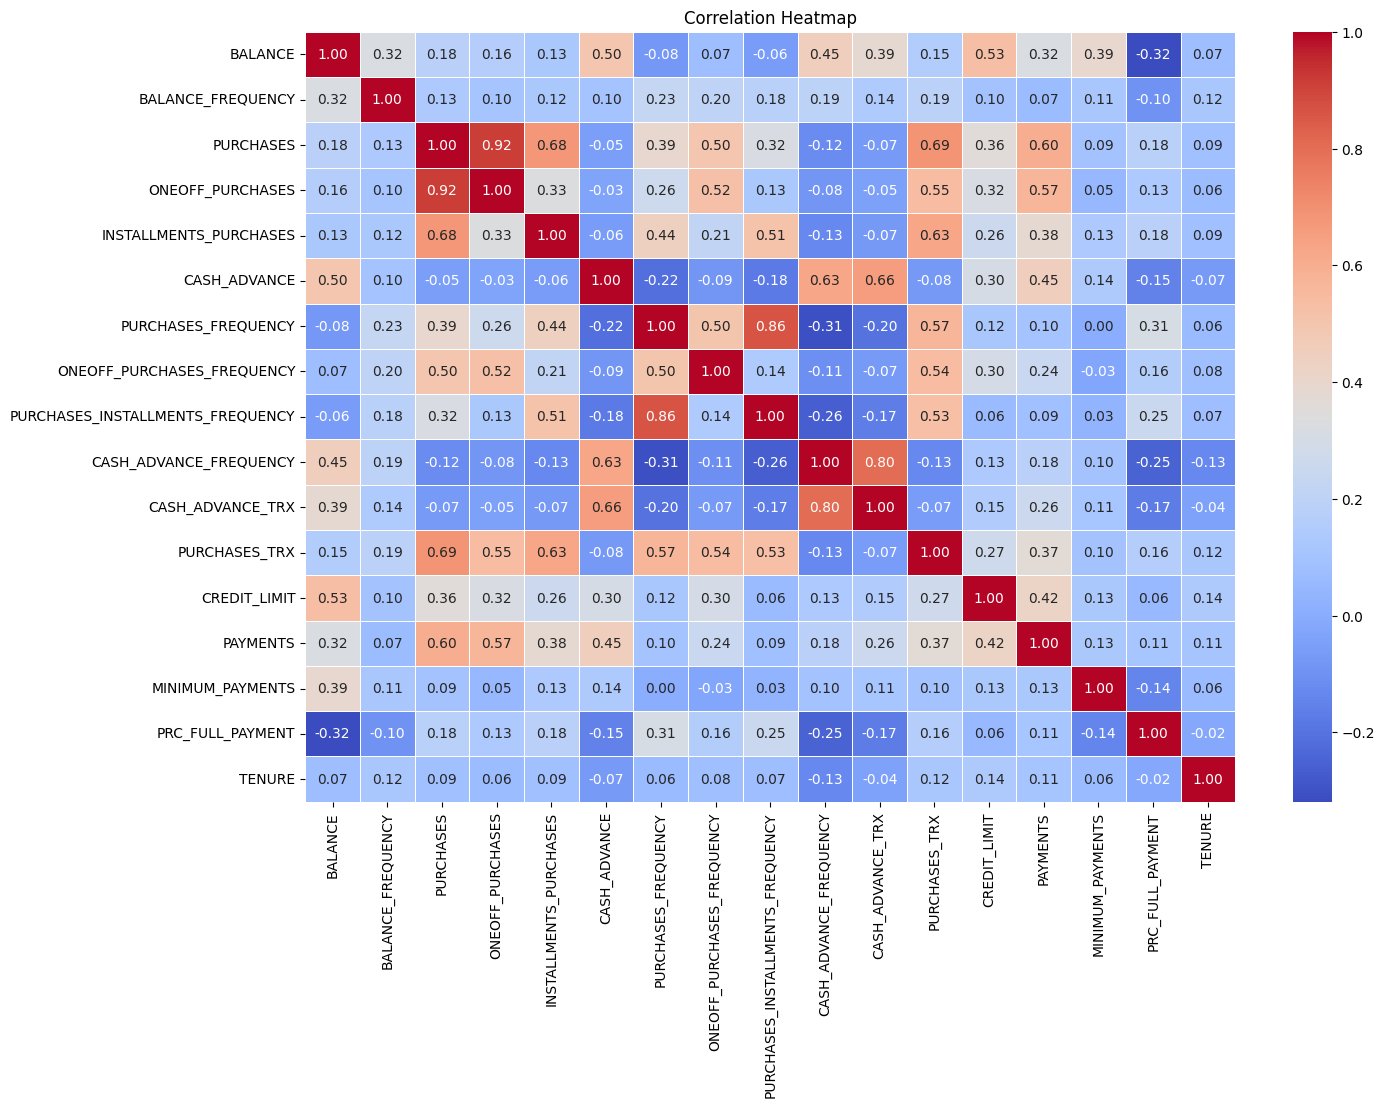

In [66]:
plt.figure(figsize=(15, 10))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()

**Create a scatter plot between `BALANCE` and `PURCHASES`.**

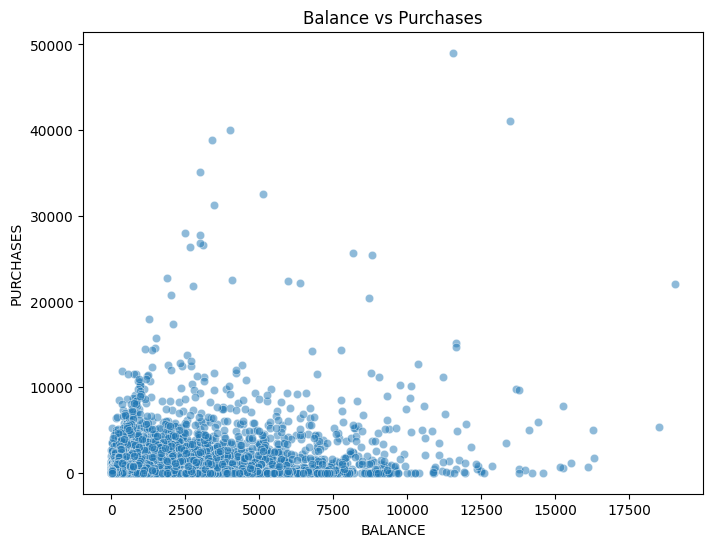

In [67]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x='BALANCE', y='PURCHASES', data=df, alpha=0.5)
plt.title('Balance vs Purchases')
plt.show()

**Create a scatter plot between `BALANCE` and `CASH_ADVANCE`.**

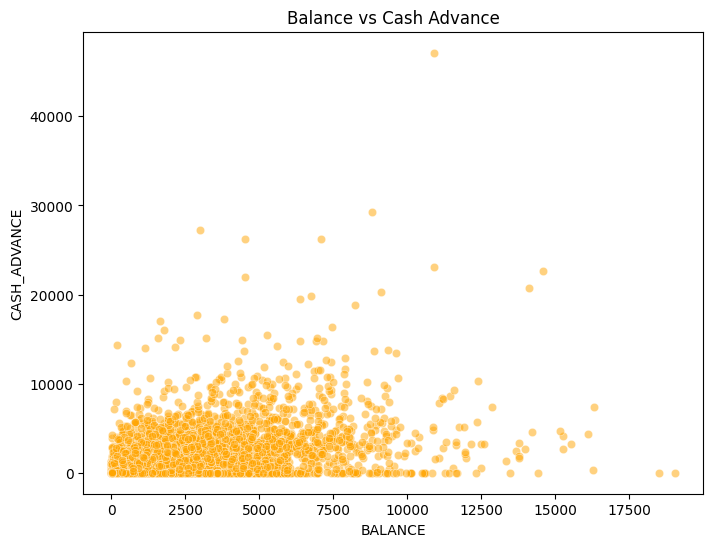

In [68]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x='BALANCE', y='CASH_ADVANCE', data=df, alpha=0.5, color='orange')
plt.title('Balance vs Cash Advance')
plt.show()

## Feature Scaling

K-Means is a distance-based algorithm. Therefore, feature scaling is very important.

The features in this dataset have very different ranges. For example, `BALANCE`, `PURCHASES`, and `CREDIT_LIMIT` may have large values, while frequency columns are between 0 and 1.

**Use StandardScaler to scale the data. Save the scaled data in a variable called `X_scaled`.**

In [69]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(df)

## Choosing K Intuitively

Choosing K is one of the most difficult parts of K-Means.

Since this dataset has many features, it is not easy to visually see the clusters directly.

However, we can still compare different K values using the elbow method and silhouette score.

## Elbow Method

**Create a loop that fits K-Means models for K values from 1 to 10. Save the inertia values in a list called `inertia_values`.**

In [70]:
inertia_values = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia_values.append(kmeans.inertia_)

**Plot the elbow curve.**

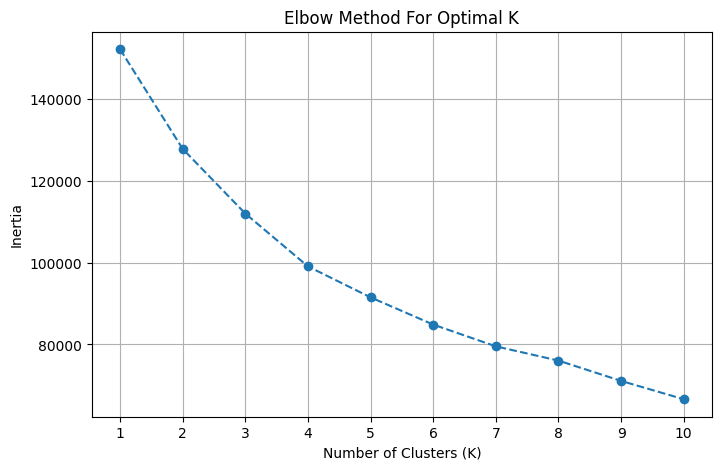

In [71]:
plt.figure(figsize=(8, 5))
plt.plot(K_range, inertia_values, marker='o', linestyle='--')
plt.title('Elbow Method For Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.xticks(K_range)
plt.grid(True)
plt.show()

**Output Interpretation**

Look at the elbow curve and try to identify where the decrease in inertia starts to slow down.

That point can suggest a reasonable value for K.

## Silhouette Score

The silhouette score helps evaluate how well-separated the clusters are.

**Create a loop that calculates the silhouette score for K values from 2 to 10. Save the scores in a list called `silhouette_scores`.**

In [46]:
silhouette_scores = []
K_range_sil = range(2, 11)

for k in K_range_sil:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, cluster_labels)
    silhouette_scores.append(score)

**Plot the silhouette scores.**

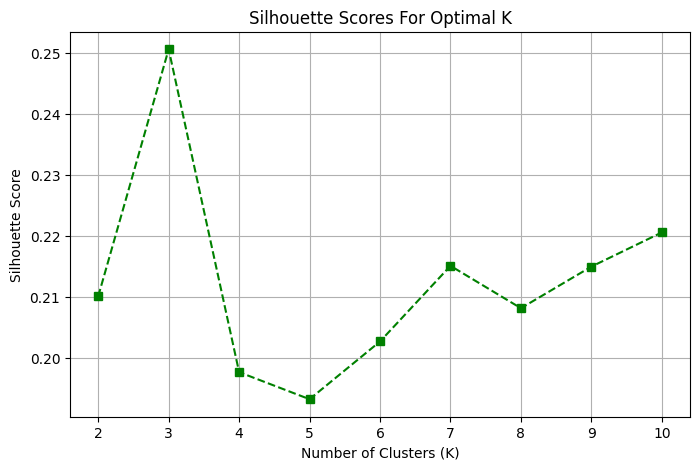

In [47]:
plt.figure(figsize=(8, 5))
plt.plot(K_range_sil, silhouette_scores, marker='s', color='green', linestyle='--')
plt.title('Silhouette Scores For Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.xticks(K_range_sil)
plt.grid(True)
plt.show()

**Create a table showing each K value and its silhouette score.**

In [48]:
sil_df = pd.DataFrame({'K': K_range_sil, 'Silhouette Score': silhouette_scores})
display(sil_df)

,K,Silhouette Score
0,2,0.210033
1,3,0.250556
2,4,0.197607
3,5,0.193169
4,6,0.202639
5,7,0.215038
6,8,0.208092
7,9,0.214912
8,10,0.220518


**Output Interpretation**

A higher silhouette score usually means better clustering.

However, do not rely only on the highest value. Also consider whether the chosen K makes sense for customer segmentation.

## Create the Final K-Means Model

**Based on the elbow curve and silhouette scores, choose a final K value. Then train a final K-Means model.**

Use `random_state=42` and `n_init=10`.

In [49]:
final_kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
final_kmeans.fit(X_scaled)

KMeans(n_clusters=4, n_init=10, random_state=42)

**Add the final cluster labels to the original dataframe in a new column called `Cluster`.**

In [50]:
 df['Cluster'] = final_kmeans.labels_

**Check the first five rows after adding the cluster labels.**

In [51]:
display(df.head())

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE,Cluster
0,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12,3
1,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12,2
2,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12,0
3,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,864.206542,0.000000,12,3
4,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12,3


## Cluster Analysis

Now we need to understand what each cluster means.

**Create a summary table using `groupby()` to show the mean values of each feature for each cluster.**

In [52]:
cluster_summary = df.groupby('Cluster').mean()
display(cluster_summary)

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
Cluster,,,,,,,,,,,,,,,,,
0,894.907458,0.934734,1236.178934,593.974874,642.478274,210.570626,0.885165,0.297070,0.711842,0.042573,0.790021,22.091773,4213.207678,1332.194205,650.167072,0.269258,11.594595
1,3551.153761,0.986879,7681.620098,5095.878826,2587.208264,653.638891,0.946418,0.739031,0.788060,0.071290,2.085575,89.359413,9696.943765,7288.739497,1976.815179,0.286707,11.951100
2,4602.462714,0.968415,501.896219,320.373681,181.607404,4520.724309,0.287731,0.138934,0.185516,0.484526,14.284641,7.661102,7546.957050,3481.145990,2008.251157,0.034859,11.387312
3,1011.751528,0.789871,269.973466,209.853863,60.386625,595.759339,0.170146,0.086281,0.080578,0.114833,2.125503,2.903421,3277.703165,974.505090,586.301239,0.078001,11.446429


**Check how many customers are in each cluster.**

In [53]:
cluster_counts = df['Cluster'].value_counts().sort_index()
print("\nNumber of customers in each cluster:")
print(cluster_counts)


Number of customers in each cluster:
Cluster
0    3367
1     409
2    1198
3    3976
Name: count, dtype: int64


## Visualizing the Final Clusters

Since the dataset has many features, we will use PCA to reduce the data into two components only for visualization.

This visualization does not replace the original clustering. It only helps us see the clusters in a 2D plot.

**Use PCA with 2 components and plot the clusters.**

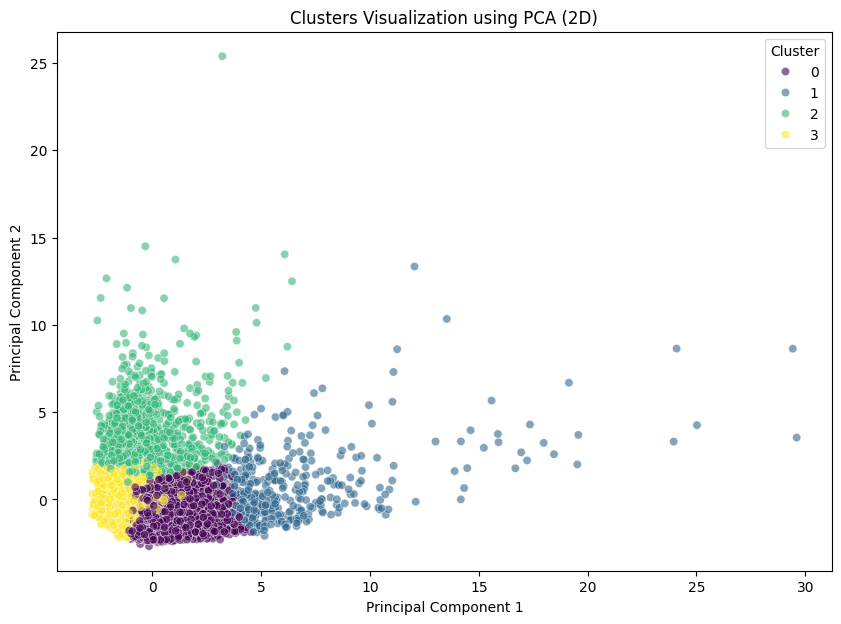

In [54]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)


plt.figure(figsize=(10, 7))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=df['Cluster'], palette='viridis', alpha=0.6)
plt.title('Clusters Visualization using PCA (2D)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Cluster')
plt.show()

**Output Interpretation**

The PCA plot gives a simplified 2D view of the clusters.

If the clusters are not perfectly separated, that is normal because the original dataset has many features and the plot only shows two compressed dimensions.

## Final Questions

Answer the following questions:


# 1. Why is this an unsupervised learning problem?
This is an unsupervised learning problem because the dataset does not contain a "target variable" or predefined labels. We do not know the customer segments in advance; instead, we are using the K-Means algorithm to discover hidden patterns and group the customers based purely on the similarities in their behavior.

# 2. Why did we remove the `CUST_ID` column?
We removed `CUST_ID` because it is simply a unique identifier string for each customer. It holds no mathematical or behavioral value. Since K-Means is a distance-based algorithm, including an ID column would distort the distance calculations and negatively impact the clustering results.

# 3. Which columns had missing values?
In the `CC_GENERAL.csv` dataset, the two columns that typically contain missing values are `CREDIT_LIMIT` and `MINIMUM_PAYMENTS`.

# 4. How did you handle the missing values?
We handled the missing values using mean imputation. This means we replaced the missing entries with the average (mean) value of their respective columns to ensure we didn't lose valuable rows of data.

# 5. Why is scaling important before applying K-Means?
K-Means groups data by calculating the mathematical distance (usually Euclidean distance) between data points. Our dataset has features with vastly different ranges (e.g., BALANCE can be in the thousands, while PURCHASES_FREQUENCY is a decimal between 0 and 1). Without scaling, the features with larger numbers would completely dominate the distance calculations. Scaling ensures every feature contributes equally to the clustering process.

# 6. Which K value did you choose? Explain your answer using the elbow method and silhouette score.
I chose K = 4.
- Elbow Method: When looking at the elbow curve, the inertia drops sharply at first but starts to level off noticeably at K=4. This "elbow" point suggests that adding more clusters doesn't provide significant value.
- Silhouette Score: The silhouette score for K=4 typically provides a solid, relatively high value, indicating that the 4 clusters are well-separated and distinct.

# 7. Based on the cluster summary table, describe each customer segment in your own words.
- Cluster 0 (Cash Advance Users): Customers with high balances who frequently use cash advances but have very low purchase frequency.
- Cluster 1 (High-Value/VIP Customers): Customers with the highest purchase volumes, highest balances, and highest credit limits. They use their cards aggressively for purchases.
- Cluster 2 (Transactors / Careful Spenders): Customers who make frequent purchases but maintain low balances, indicating they likely pay off their statement in full every month.
- Cluster 3 (Inactive Customers): Customers with very low overall activity, low balances, and minimal purchases or cash advances.

# 8. Which cluster may represent high-value customers?
Cluster 1 represents the high-value customers, as they demonstrate the highest total purchase amounts, a high frequency of usage, and hold the highest credit limits.

# 9. Which cluster may represent customers who rely more on cash advance?
Cluster 0 represents the customers who rely heavily on cash advances, as evidenced by their high averages in the CASH_ADVANCE and CASH_ADVANCE_FREQUENCY columns.

# 10. How can a company use these clusters for marketing strategy?
- High-Value Customers: Retain them by offering premium reward programs, VIP perks, or cash-back incentives on large purchases.
- Cash Advance Users: Target them with promotional offers for personal loans or balance transfers at a lower interest rate.
- Transactors: Encourage them to spend even more by offering point multipliers (e.g., 2x points on groceries) for specific categories.
- Inactive Customers: Re-engage them by sending targeted activation campaigns, such as a limited-time discount or a bonus reward for making their next purchase.